In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv('lol_clean_final.csv')

# 불필요 컬럼 제거
drop_cols = ['match_id', 'blue_heralds', 'red_heralds'] + \
            [c for c in df.columns if 'champion' in c] + \
            [c for c in df.columns if '_tag' in c] + \
            [c for c in df.columns if '_comp' in c]

df_model = df.drop(columns=drop_cols)

X = df_model.drop(columns=['win'])
y = df_model['win']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                               columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),
                               columns=X.columns, index=X_test.index)

print(f"준비 완료! 학습: {X_train.shape}, 테스트: {X_test.shape}")

준비 완료! 학습: (6728, 54), 테스트: (1682, 54)


In [4]:
team_cols = ['blue_dragons', 'blue_towers', 'blue_kills',
             'blue_firstBlood', 'blue_voidgrubs',
             'red_dragons', 'red_towers', 'red_kills', 'red_voidgrubs']

sc_team = StandardScaler()
X_train_team = pd.DataFrame(sc_team.fit_transform(X_train[team_cols]),
                              columns=team_cols, index=X_train.index)
X_test_team  = pd.DataFrame(sc_team.transform(X_test[team_cols]),
                              columns=team_cols, index=X_test.index)

# LR
lr_v1 = LogisticRegression(max_iter=1000, random_state=42)
lr_v1.fit(X_train_team, y_train)

# RF
rf_v1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_v1.fit(X_train[team_cols], y_train)

# XGBoost
xgb_v1 = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                        eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_v1.fit(X_train[team_cols], y_train)

v1_results = pd.DataFrame({
    '모델': ['LR', 'RF', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, lr_v1.predict(X_test_team)),
                 accuracy_score(y_test, rf_v1.predict(X_test[team_cols])),
                 accuracy_score(y_test, xgb_v1.predict(X_test[team_cols]))],
    'F1':       [f1_score(y_test, lr_v1.predict(X_test_team)),
                 f1_score(y_test, rf_v1.predict(X_test[team_cols])),
                 f1_score(y_test, xgb_v1.predict(X_test[team_cols]))],
    'ROC-AUC':  [roc_auc_score(y_test, lr_v1.predict_proba(X_test_team)[:,1]),
                 roc_auc_score(y_test, rf_v1.predict_proba(X_test[team_cols])[:,1]),
                 roc_auc_score(y_test, xgb_v1.predict_proba(X_test[team_cols])[:,1])]
})

print("=== 버전1: 팀 단위 피처만 ===")
print(v1_results.round(4).to_string(index=False))

=== 버전1: 팀 단위 피처만 ===
     모델  Accuracy     F1  ROC-AUC
     LR    0.7675 0.7614   0.8467
     RF    0.7479 0.7402   0.8150
XGBoost    0.7675 0.7614   0.8453


In [5]:
# LR
lr_v2 = LogisticRegression(max_iter=1000, random_state=42)
lr_v2.fit(X_train_scaled, y_train)

# RF
rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_v2.fit(X_train, y_train)

# XGBoost
xgb_v2 = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                        eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_v2.fit(X_train, y_train)

v2_results = pd.DataFrame({
    '모델': ['LR', 'RF', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, lr_v2.predict(X_test_scaled)),
                 accuracy_score(y_test, rf_v2.predict(X_test)),
                 accuracy_score(y_test, xgb_v2.predict(X_test))],
    'F1':       [f1_score(y_test, lr_v2.predict(X_test_scaled)),
                 f1_score(y_test, rf_v2.predict(X_test)),
                 f1_score(y_test, xgb_v2.predict(X_test))],
    'ROC-AUC':  [roc_auc_score(y_test, lr_v2.predict_proba(X_test_scaled)[:,1]),
                 roc_auc_score(y_test, rf_v2.predict_proba(X_test)[:,1]),
                 roc_auc_score(y_test, xgb_v2.predict_proba(X_test)[:,1])]
})

print("=== 버전2: 라인 피처 추가 ===")
print(v2_results.round(4).to_string(index=False))

=== 버전2: 라인 피처 추가 ===
     모델  Accuracy     F1  ROC-AUC
     LR    0.7860 0.7800   0.8653
     RF    0.7693 0.7614   0.8535
XGBoost    0.7765 0.7682   0.8547


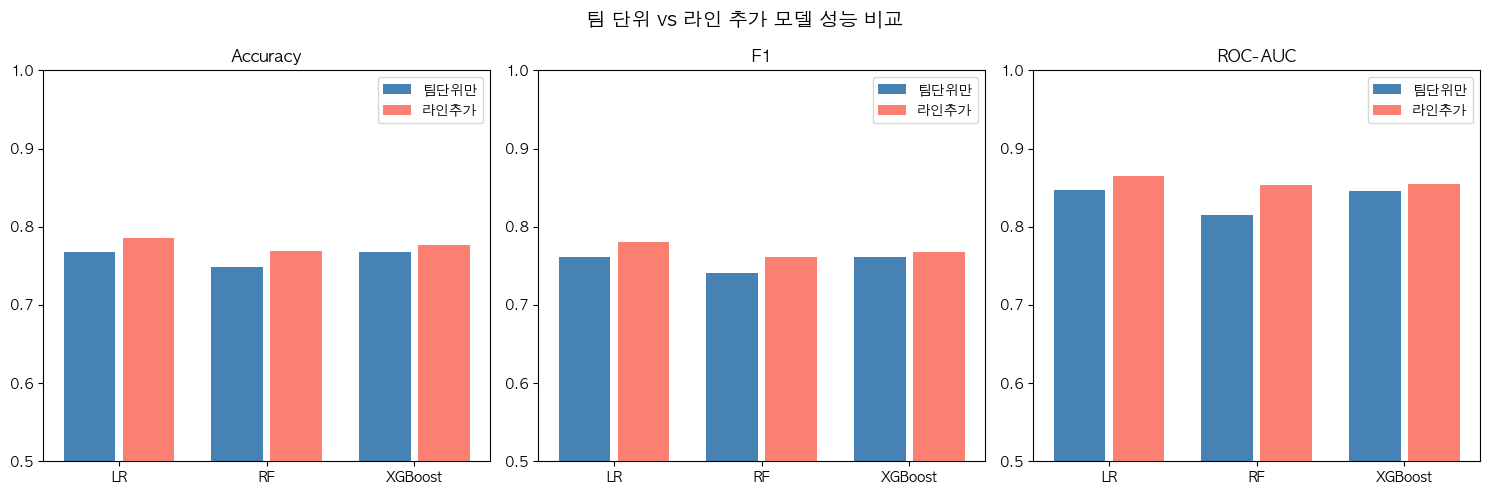


=== 버전1 ===
     모델  Accuracy     F1  ROC-AUC
     LR    0.7675 0.7614   0.8467
     RF    0.7479 0.7402   0.8150
XGBoost    0.7675 0.7614   0.8453

=== 버전2 ===
     모델  Accuracy     F1  ROC-AUC
     LR    0.7860 0.7800   0.8653
     RF    0.7693 0.7614   0.8535
XGBoost    0.7765 0.7682   0.8547


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Accuracy', 'F1', 'ROC-AUC']

for i, metric in enumerate(metrics):
    x = range(3)
    axes[i].bar([j-0.2 for j in x], v1_results[metric],
                0.35, label='팀단위만', color='steelblue')
    axes[i].bar([j+0.2 for j in x], v2_results[metric],
                0.35, label='라인추가', color='salmon')
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(['LR', 'RF', 'XGBoost'])
    axes[i].set_title(metric)
    axes[i].set_ylim(0.5, 1.0)
    axes[i].legend()

plt.suptitle('팀 단위 vs 라인 추가 모델 성능 비교', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== 버전1 ===")
print(v1_results.round(4).to_string(index=False))
print("\n=== 버전2 ===")
print(v2_results.round(4).to_string(index=False))

교차검증 실행 중...
  V1_LR 완료
  V1_RF 완료
  V1_XGBoost 완료
  V2_LR 완료
  V2_RF 완료
  V2_XGBoost 완료
완료!

=== 단순 분할 vs 교차검증 비교 ===
모델               단순-Acc             CV-Acc      단순-F1              CV-F1     단순-AUC             CV-AUC
------------------------------------------------------------------------------------------------------
V1_LR             76.8%        76.6% ±0.9%      76.1%        76.0% ±0.7%      84.7%        84.8% ±0.7%
V1_RF             74.8%        73.2% ±0.9%      74.0%        72.5% ±1.1%      81.5%        80.8% ±0.8%
V1_XGBoost        76.8%        76.0% ±0.9%      76.1%        75.4% ±0.5%      84.5%        84.5% ±0.6%
V2_LR             78.6%        77.7% ±1.2%      78.0%        77.1% ±1.2%      86.5%        86.4% ±0.9%
V2_RF             76.9%        76.8% ±0.5%      76.1%        76.0% ±0.5%      85.4%        85.1% ±0.8%
V2_XGBoost        77.6%        76.5% ±0.6%      76.8%        76.0% ±0.5%      85.5%        85.2% ±0.8%


KeyError: 'ROCAUC'

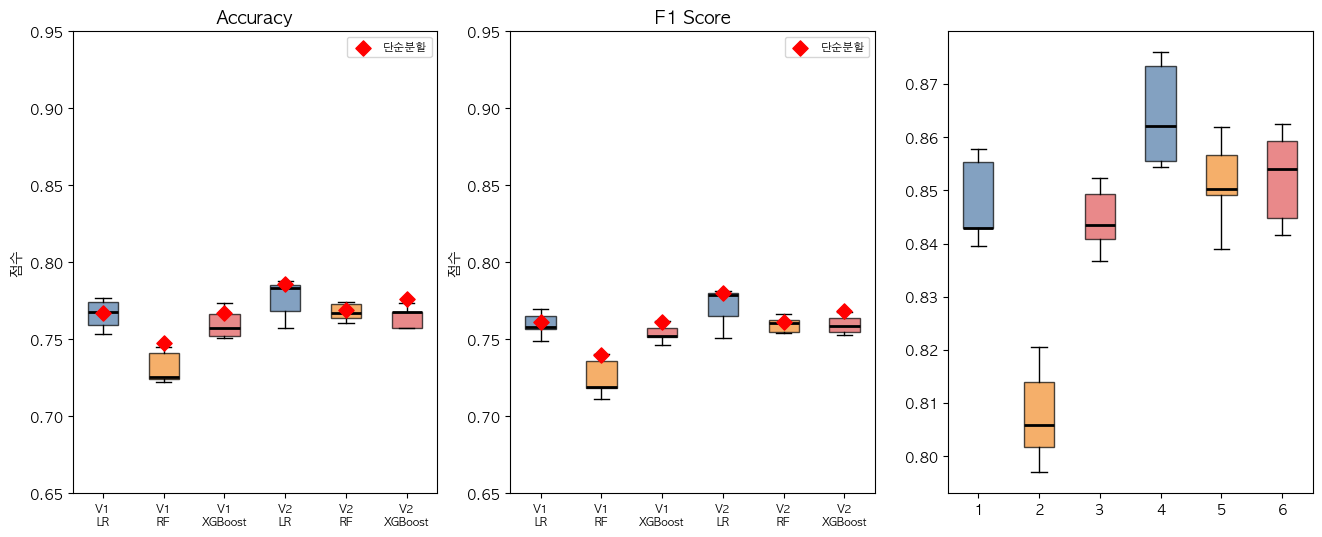

In [7]:
# ── 교차검증: V1/V2 모델 StratifiedKFold 5-fold ────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_validate
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 준비 ──
df = pd.read_csv('lol_clean_final.csv')
drop_cols = ['match_id', 'blue_heralds', 'red_heralds'] + \
            [c for c in df.columns if 'champion' in c] + \
            [c for c in df.columns if '_tag' in c] + \
            [c for c in df.columns if '_comp' in c]
df_model = df.drop(columns=drop_cols)
X_all = df_model.drop(columns=['win'])
y     = df_model['win']

team_cols = ['blue_dragons', 'blue_towers', 'blue_kills',
             'blue_firstBlood', 'blue_voidgrubs',
             'red_dragons', 'red_towers', 'red_kills', 'red_voidgrubs']
X_team = X_all[team_cols]

# ── 단순 분할 결과 (기존) ──
single_split = {
    'V1_LR':      {'Accuracy': 0.7675, 'F1': 0.7614, 'ROC-AUC': 0.8467},
    'V1_RF':      {'Accuracy': 0.7479, 'F1': 0.7402, 'ROC-AUC': 0.8150},
    'V1_XGBoost': {'Accuracy': 0.7675, 'F1': 0.7614, 'ROC-AUC': 0.8453},
    'V2_LR':      {'Accuracy': 0.7860, 'F1': 0.7800, 'ROC-AUC': 0.8653},
    'V2_RF':      {'Accuracy': 0.7693, 'F1': 0.7614, 'ROC-AUC': 0.8535},
    'V2_XGBoost': {'Accuracy': 0.7765, 'F1': 0.7682, 'ROC-AUC': 0.8547},
}

# ── 교차검증 설정 ──
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc']

def run_cv(estimator, X, label):
    cv_res = cross_validate(estimator, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    return {
        'label':   label,
        'acc':     cv_res['test_accuracy'],
        'f1':      cv_res['test_f1'],
        'roc_auc': cv_res['test_roc_auc'],
    }

# 스케일러는 cross_validate 내부에서 데이터 누수 없이 쓰기 위해 Pipeline 사용
from sklearn.pipeline import Pipeline

models_v1 = [
    ('V1_LR',      Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=1000, random_state=42))]),      X_team),
    ('V1_RF',      RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),                                 X_team),
    ('V1_XGBoost', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42, n_jobs=-1), X_team),
]
models_v2 = [
    ('V2_LR',      Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=1000, random_state=42))]),      X_all),
    ('V2_RF',      RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),                                 X_all),
    ('V2_XGBoost', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42, n_jobs=-1), X_all),
]

print('교차검증 실행 중...')
cv_results = {}
for name, model, X in models_v1 + models_v2:
    cv_results[name] = run_cv(model, X, name)
    print(f'  {name} 완료')
print('완료!')

# ── 비교표 출력 ──
print('\n=== 단순 분할 vs 교차검증 비교 ===')
header = f"{'모델':<12} {'단순-Acc':>10} {'CV-Acc':>18} {'단순-F1':>10} {'CV-F1':>18} {'단순-AUC':>10} {'CV-AUC':>18}"
print(header)
print('-' * len(header))
for name, res in cv_results.items():
    ss = single_split[name]
    acc_cv  = f"{res['acc'].mean()*100:.1f}% ±{res['acc'].std()*100:.1f}%"
    f1_cv   = f"{res['f1'].mean()*100:.1f}% ±{res['f1'].std()*100:.1f}%"
    auc_cv  = f"{res['roc_auc'].mean()*100:.1f}% ±{res['roc_auc'].std()*100:.1f}%"
    print(f"{name:<12} {ss['Accuracy']*100:>9.1f}% {acc_cv:>18} "
          f"{ss['F1']*100:>9.1f}% {f1_cv:>18} "
          f"{ss['ROC-AUC']*100:>9.1f}% {auc_cv:>18}")

# ── 박스플롯 시각화 ──
metrics     = [('acc', 'Accuracy'), ('f1', 'F1 Score'), ('roc_auc', 'ROC-AUC')]
model_names = list(cv_results.keys())
colors      = ['#4e79a7','#f28e2b','#e15759'] * 2

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (metric_key, metric_name) in zip(axes, metrics):
    data   = [cv_results[n][metric_key] for n in model_names]
    labels = [n.replace('_', '\n') for n in model_names]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # 단순 분할 결과 점 표시
    for i, name in enumerate(model_names, 1):
        ss_val = single_split[name][metric_name.replace(' Score','').replace('-','').replace(' ','')]
        if metric_name == 'ROC-AUC':
            ss_val = single_split[name]['ROC-AUC']
        elif metric_name == 'F1 Score':
            ss_val = single_split[name]['F1']
        else:
            ss_val = single_split[name]['Accuracy']
        ax.scatter(i, ss_val, color='red', zorder=5, s=60, marker='D', label='단순분할' if i==1 else '')

    ax.set_xticks(range(1, len(model_names)+1))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(metric_name, fontsize=13)
    ax.set_ylabel('점수')
    ax.set_ylim(0.65, 0.95)
    if metric_key == 'roc_auc':
        ax.set_ylim(0.80, 0.92)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.legend(fontsize=8)

# V1/V2 구분선
for ax in axes:
    ax.axvline(3.5, color='gray', linestyle='--', linewidth=1)
    ax.text(2, ax.get_ylim()[0] + 0.005, 'V1 (팀단위)', ha='center', fontsize=9, color='gray')
    ax.text(5, ax.get_ylim()[0] + 0.005, 'V2 (라인추가)', ha='center', fontsize=9, color='gray')

plt.suptitle('5-Fold 교차검증 점수 분포  (◆ = 단순 분할 결과)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── XGBoost 하이퍼파라미터 튜닝 (Optuna, V2 피처셋) ──────────────────────
import pandas as pd
import numpy as np
import optuna
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 준비 ──────────────────────────────────────────────────────────
df = pd.read_csv('lol_clean_final.csv')
drop_cols = ['match_id', 'blue_heralds', 'red_heralds'] + \
            [c for c in df.columns if 'champion' in c] + \
            [c for c in df.columns if '_tag' in c] + \
            [c for c in df.columns if '_comp' in c]
df_model = df.drop(columns=drop_cols)
X = df_model.drop(columns=['win'])
y = df_model['win']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 튜닝 전 베이스라인 성능 ───────────────────────────────────────────────
xgb_base = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
base_scores = cross_val_score(xgb_base, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
base_auc  = base_scores.mean()
base_std  = base_scores.std()
print(f"[베이스라인] ROC-AUC: {base_auc:.4f} ± {base_std:.4f}")

# ── Optuna 목적함수 ───────────────────────────────────────────────────────
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# ── 튜닝 실행 (50회) ─────────────────────────────────────────────────────
print("Optuna 탐색 시작 (50 trials)...")
study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_auc_cv = study.best_value
print(f"\n[튜닝 완료] 최고 ROC-AUC: {best_auc_cv:.4f}")

# ── 최적 파라미터로 재학습 및 CV 평가 ────────────────────────────────────
xgb_tuned = XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
tuned_scores = cross_val_score(xgb_tuned, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
tuned_auc = tuned_scores.mean()
tuned_std = tuned_scores.std()

# 전체 데이터로 최종 학습 후 저장
xgb_tuned.fit(X, y)
joblib.dump(xgb_tuned, 'xgb_tuned.pkl')
print("모델 저장 완료: xgb_tuned.pkl")

# ── 최적 파라미터 출력 ────────────────────────────────────────────────────
print("\n=== 최적 파라미터 ===")
for k, v in best_params.items():
    default = {'n_estimators': 200, 'max_depth': 4,
               'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 1.0}
    arrow = '▲' if (isinstance(v, float) and v > default.get(k, v)) or \
                   (isinstance(v, int)   and v > default.get(k, v)) else '▼'
    print(f"  {k:<20}: {v:.4f}  (기본값: {default.get(k, '-')})")

# ── 성능 비교표 ───────────────────────────────────────────────────────────
print("\n=== 튜닝 전후 성능 비교 (5-Fold CV ROC-AUC) ===")
print(f"{'':20} {'ROC-AUC 평균':>14} {'표준편차':>10} {'향상폭':>10}")
print("-" * 56)
print(f"{'XGBoost (기본값)':20} {base_auc:>13.4f} {base_std:>10.4f} {'기준':>10}")
print(f"{'XGBoost (Optuna)':20} {tuned_auc:>13.4f} {tuned_std:>10.4f} {tuned_auc-base_auc:>+10.4f}")

# ── 시각화: trial 진행에 따른 AUC 변화 + 최적값 비교 ────────────────────
trial_values = [t.value for t in study.trials]
best_so_far  = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: trial별 AUC 추이
axes[0].scatter(range(1, len(trial_values)+1), trial_values,
                alpha=0.4, s=20, color='steelblue', label='각 trial AUC')
axes[0].plot(range(1, len(best_so_far)+1), best_so_far,
             color='red', linewidth=2, label='최고 AUC 추이')
axes[0].axhline(base_auc, color='gray', linestyle='--', linewidth=1.5,
                label=f'기본값 {base_auc:.4f}')
axes[0].set_xlabel('Trial 번호')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Optuna 탐색 과정 — Trial별 ROC-AUC', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 오른쪽: 튜닝 전후 박스플롯 비교
axes[1].boxplot([base_scores, tuned_scores],
                labels=['기본값\n(n_est=200,depth=4\nlr=0.05)',
                        f'Optuna 최적\n(n_est={best_params["n_estimators"]},depth={best_params["max_depth"]}\nlr={best_params["learning_rate"]:.3f})'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('ROC-AUC (5-Fold)')
axes[1].set_title('튜닝 전 vs 후 성능 분포', fontsize=13)
axes[1].grid(alpha=0.3, axis='y')
for i, (scores, label) in enumerate([(base_scores, base_auc), (tuned_scores, tuned_auc)], 1):
    axes[1].text(i, label + 0.001, f'{label:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('XGBoost Optuna 하이퍼파라미터 튜닝 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
